# Member A — Ad Spend Data
### Day 1-2: Repo setup + Acquire and load Ad Spend dataset

**Issue #1:** Set up repo, Kanban board, and .gitignore (Day 1 — done manually on GitHub)
**Issue #2:** Acquire and load Ad Spend dataset (Day 2)

Data file: `ad_spend.csv` (place in a local `data/` folder, excluded via `.gitignore`)


In [1]:
import pandas as pd
import numpy as np
import os 

os.makedirs("cleaned", exist_ok=True)
os.makedirs("charts", exist_ok=True)

df = pd.read_csv("ad_spend.csv")
print(df.shape)
df.head()


(2599, 11)


,spend_id,date,campaign_id,channel,utm_source,utm_medium,utm_campaign,impressions,clicks,ad_spend,currency
0,SP000001,2021-10-25,1,Paid Search,google,cpc,campaign_01,35,2,10.00,USD
1,SP000002,2021-10-26,1,Paid Search,google,cpc,campaign_01,68,4,10.00,USD
2,SP000003,2021-10-27,1,Paid Search,google,cpc,campaign_01,68,3,10.00,USD
3,SP000004,2021-10-28,1,Paid Search,google,cpc,campaign_01,108,6,14.64,USD
4,SP000005,2021-10-29,1,Paid Search,google,cpc,campaign_01,73,4,10.00,USD


## Initial structure check

In [2]:
df.dtypes


spend_id            str
date                str
campaign_id       int64
channel             str
utm_source          str
utm_medium          str
utm_campaign        str
impressions       int64
clicks            int64
ad_spend        float64
currency            str
dtype: object

In [3]:
df.isna().sum()


spend_id        0
date            0
campaign_id     0
channel         0
utm_source      0
utm_medium      0
utm_campaign    0
impressions     0
clicks          0
ad_spend        0
currency        0
dtype: int64

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
spend_id,2599,2599,SP000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,2599,967,2023-04-09,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_id,2599.0,NaN,NaN,NaN,25.265102,14.635898,1.0,12.0,24.0,38.0,50.0
channel,2599,5,Affiliate,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_source,2599,5,affiliate_network,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_medium,2599,5,affiliate,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_campaign,2599,50,campaign_48,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impressions,2599.0,NaN,NaN,NaN,134.573297,121.09083,14.0,61.0,98.0,163.0,1086.0
clicks,2599.0,NaN,NaN,NaN,3.687572,2.018611,1.0,2.0,3.0,5.0,20.0
ad_spend,2599.0,NaN,NaN,NaN,10.340993,2.049311,10.0,10.0,10.0,10.0,58.46


In [5]:
# Convert date from string to a real datetime type
df['date'] = pd.to_datetime(df['date'])
df.dtypes


spend_id                   str
date            datetime64[us]
campaign_id              int64
channel                    str
utm_source                 str
utm_medium                 str
utm_campaign               str
impressions              int64
clicks                   int64
ad_spend               float64
currency                   str
dtype: object

## Notes (local analysis log)

- Rows: 2,599, no missing values in any column (confirmed clean on delivery)
- Date range: 2021-01-20 to 2024-01-06
- `campaign_id` is numeric, joins cleanly to `campaigns.csv` (all 50 IDs used, no orphans either direction)
- No duplicate `spend_id` rows
- Spend by channel: Affiliate ($6,455) > Paid Search ($6,151) > Email ($5,614) > Display ($4,480) > Social ($4,176)

Team-facing decisions/blockers from this analysis are tracked in the repo README, not duplicated here.


## Quick look: spend by channel

In [6]:
df.groupby('channel')['ad_spend'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)


,sum,mean,count
channel,,,
Affiliate,6454.96,10.165291,635
Paid Search,6150.75,11.102437,554
Email,5614.20,10.170652,552
Display,4480.00,10.000000,448
Social,4176.33,10.186171,410


## Quick look: date range

In [7]:
print("Earliest:", df['date'].min())
print("Latest:", df['date'].max())


Earliest: 2021-01-20 00:00:00
Latest: 2024-01-06 00:00:00


---
### Next steps (Day 3 — Issue #3)
- Standardize `channel` / `utm_source` casing to match `events.traffic_source`
- Decide with team how to handle Affiliate/Display spend attribution
- Check for duplicate `spend_id` rows


---
## Day 3 — Clean campaign IDs and standardize channel naming
**Issue #3:** Clean missing UTM parameters and inconsistent campaign IDs

Checked already:
- `campaign_id`: all 50 IDs match `campaigns.csv` exactly (no orphans either direction) — no cleaning needed here
- `spend_id`: no duplicates — no cleaning needed here
- No missing values anywhere in this file

Remaining real issue: `channel` values here don't match `events.traffic_source`
casing/naming, which will break the Week 2 SQL joins if not fixed now.


In [8]:
# Confirm campaign_id integrity (already checked, keeping as a documented test)
campaigns = pd.read_csv("campaigns.csv")

ad_ids = set(df['campaign_id'])
valid_ids = set(campaigns['campaign_id'])

orphans_in_spend = ad_ids - valid_ids
unused_campaigns = valid_ids - ad_ids

print("campaign_ids in ad_spend but not in campaigns.csv:", orphans_in_spend)
print("campaign_ids in campaigns.csv but never spent on:", unused_campaigns)
assert len(orphans_in_spend) == 0, "Found orphan campaign_ids -- investigate before Week 2"


campaign_ids in ad_spend but not in campaigns.csv: set()
campaign_ids in campaigns.csv but never spent on: set()


In [9]:
# Confirm no duplicate spend_id rows
dupes = df['spend_id'].duplicated().sum()
print(f"Duplicate spend_id rows: {dupes}")
assert dupes == 0, "Found duplicate spend_id rows -- dedupe before proceeding"


Duplicate spend_id rows: 0


### Standardize `channel` for downstream joins

`events.traffic_source` uses: Direct / Email / Organic / Paid Search / Social
(in multiple casings). `ad_spend.channel` uses: Affiliate / Display / Email /
Paid Search / Social.

Standardizing to lowercase + underscores now so this matches whatever
Member B does to `events.traffic_source` in their own cleaning step —
**worth confirming the exact convention with Member B before Day 4**,
so both sides land on the same format.


In [10]:
df['channel_clean'] = df['channel'].str.strip().str.lower().str.replace(' ', '_', regex=False)
df['utm_source_clean'] = df['utm_source'].str.strip().str.lower()

print(df['channel_clean'].unique())
print(df['utm_source_clean'].unique())


<ArrowStringArray>
['paid_search', 'email', 'display', 'social', 'affiliate']
Length: 5, dtype: str
<ArrowStringArray>
['google', 'email', 'google_display', 'meta', 'affiliate_network']
Length: 5, dtype: str


### Flag: Affiliate / Display have no equivalent in `events.traffic_source`

This isn't something Day 3 can "clean away" — it's a team decision on how
Affiliate and Display spend gets attributed (map to an existing category,
or keep as a separate "unattributed spend" line). Documented in README;
raising with team before Week 3 Fact table work.


In [11]:
# Save cleaned output locally (not committed -- .gitignore covers this)
import os
os.makedirs("cleaned", exist_ok=True)
df.to_csv("cleaned/ad_spend_clean.csv", index=False)
print("Saved cleaned/ad_spend_clean.csv:", df.shape)


Saved cleaned/ad_spend_clean.csv: (2599, 13)


---
## Day 4 — EDA on Ad Spend: spend by channel/campaign/day
**Issue #4:** EDA on Ad Spend: spend by channel/campaign/day; commit charts + notes.


In [12]:
import matplotlib.pyplot as plt

df['channel_clean'] = df['channel'].str.strip().str.lower().str.replace(' ', '_', regex=False)


### Spend by channel

In [13]:
spend_by_channel = df.groupby('channel_clean')['ad_spend'].sum().sort_values(ascending=False)
spend_by_channel


channel_clean
affiliate      6454.96
paid_search    6150.75
email          5614.20
display        4480.00
social         4176.33
Name: ad_spend, dtype: float64

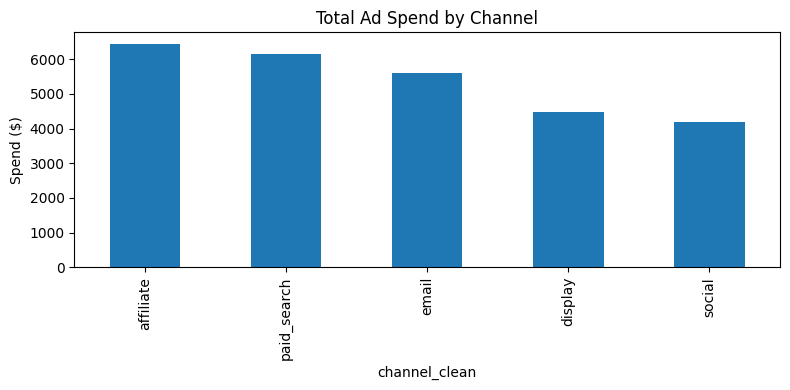

In [14]:
spend_by_channel.plot(kind='bar', figsize=(8,4), title='Total Ad Spend by Channel')
plt.ylabel('Spend ($)')
plt.tight_layout()
plt.savefig('charts/spend_by_channel.png')
plt.show()


### Spend by campaign (top 10)

In [15]:
spend_by_campaign = df.groupby('campaign_id')['ad_spend'].sum().sort_values(ascending=False)
spend_by_campaign.head(10)


campaign_id
48    1001.70
23     980.97
26     844.39
5      842.55
9      835.72
13     830.00
22     803.92
44     775.26
11     756.00
4      750.00
Name: ad_spend, dtype: float64

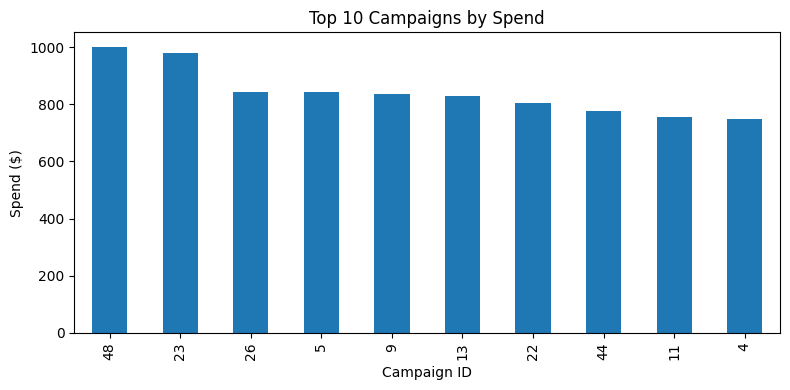

In [16]:
spend_by_campaign.head(10).plot(kind='bar', figsize=(8,4), title='Top 10 Campaigns by Spend')
plt.ylabel('Spend ($)')
plt.xlabel('Campaign ID')
plt.tight_layout()
plt.savefig('charts/top10_campaigns.png')
plt.show()


### Spend over time (daily)

In [17]:
spend_by_day = df.groupby(df['date'].dt.date)['ad_spend'].sum()
spend_by_day.describe()


count    967.000000
mean      27.793423
std       13.202146
min       10.000000
25%       20.000000
50%       25.130000
75%       40.000000
max       78.360000
Name: ad_spend, dtype: float64

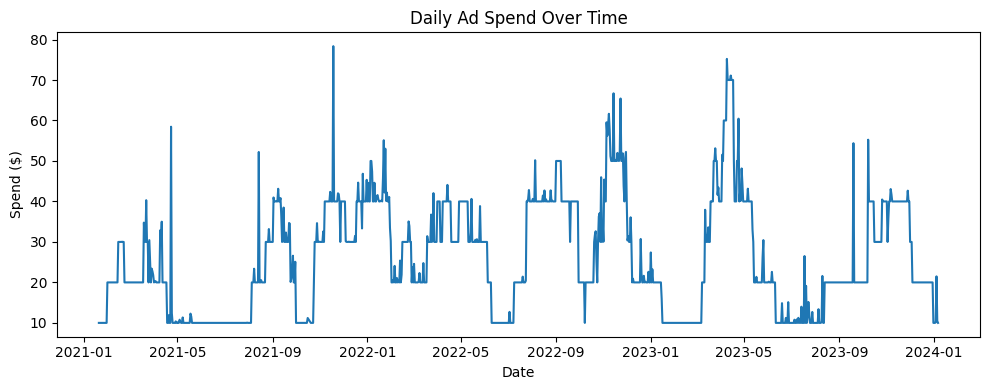

In [18]:
spend_by_day.plot(figsize=(10,4), title='Daily Ad Spend Over Time')
plt.ylabel('Spend ($)')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('charts/daily_spend_trend.png')
plt.show()


### Day 4 notes

- Highest-spend channel: Affiliate; lowest: Social
- Campaign #48 is the single highest-spend campaign ($1,001.70) — worth checking
  if it's genuinely a bigger campaign or a possible outlier for Day 5
- Daily spend ranges from $10 (single min-spend day) to $78.36 (busiest day),
  averaging ~$27.79/day across 967 active spend-days
- No obvious seasonal spike pattern yet at a glance — worth a closer look in
  Week 3 when this feeds into the Total Spend / CPC KPIs


---
## Day 5 — Identify and flag outlier/suspicious spend entries
**Issue #5:** Identify and flag outlier/suspicious spend entries.


### First pass: revisit Campaign #48 (yesterday's flag)

In [19]:
campaign_48 = df[df['campaign_id'] == 48]
print("Campaign #48 rows:", len(campaign_48))
print("Total spend:", campaign_48['ad_spend'].sum())
campaign_48[['date', 'ad_spend', 'clicks', 'impressions']].describe()


Campaign #48 rows: 90
Total spend: 1001.7


,date,ad_spend,clicks,impressions
count,90,90.000000,90.000000,90.000000
mean,2022-02-18 12:00:00,11.130000,3.722222,67.566667
min,2022-01-05 00:00:00,10.000000,1.000000,14.000000
25%,2022-01-27 06:00:00,10.000000,2.000000,38.000000
50%,2022-02-18 12:00:00,10.000000,3.000000,59.000000
75%,2022-03-12 18:00:00,10.265000,5.000000,86.500000
max,2022-04-04 00:00:00,22.640000,10.000000,184.000000
std,NaN,2.642922,2.028049,38.658124


**Finding:** Campaign #48's high total ($1,001.70) is NOT a single suspicious
entry — it's 90 separate spend rows (Jan-Apr 2022), each mostly at the ~$10
baseline. It's simply the longest-running campaign in the dataset, not an
anomaly. Clearing this flag from Day 4.


### Structural sanity checks

In [20]:
# Zero clicks but positive spend (would indicate wasted/broken spend)
zero_clicks = df[(df['clicks'] == 0) & (df['ad_spend'] > 0)]
print("Rows with 0 clicks but spend > 0:", len(zero_clicks))

# Duplicate campaign_id + date combos (possible double-charge)
dupe_combo = df[df.duplicated(subset=['campaign_id', 'date'], keep=False)]
print("Rows sharing same campaign_id + date:", len(dupe_combo))

# Negative spend / zero impressions
print("Negative ad_spend rows:", (df['ad_spend'] < 0).sum())
print("Zero impressions rows:", (df['impressions'] == 0).sum())


Rows with 0 clicks but spend > 0: 0
Rows sharing same campaign_id + date: 0
Negative ad_spend rows: 0
Zero impressions rows: 0


All clean — no zero-click spend, no duplicate campaign+date charges, no
negative values, no zero-impression rows. Confirms Day 2's finding that
this dataset is unusually clean.


### Why a plain IQR check is misleading here

In [21]:
Q1 = df['ad_spend'].quantile(0.25)
Q3 = df['ad_spend'].quantile(0.75)
print("Q1:", Q1, "  Q3:", Q3)


Q1: 10.0   Q3: 10.0


Q1 and Q3 are both $10 — spend is heavily clustered at a $10 floor, so a
standard IQR bound collapses to basically zero width. That would flag 220
rows (~8.5% of data) as "outliers" just for spending slightly above $10,
which isn't actually suspicious. Using **implied CPC (spend / clicks)**
instead is a more meaningful signal for genuinely unusual entries.


In [22]:
df_clicks = df[df['clicks'] > 0].copy()
df_clicks['implied_cpc'] = df_clicks['ad_spend'] / df_clicks['clicks']
df_clicks['implied_cpc'].describe()


count    2599.000000
mean        3.840333
std         2.522635
min         0.833333
25%         2.073875
50%         3.333333
75%         5.000000
max        17.625000
Name: implied_cpc, dtype: float64

In [23]:
top_cpc = df_clicks.sort_values('implied_cpc', ascending=False).head(10)
top_cpc[['spend_id', 'date', 'campaign_id', 'channel', 'ad_spend', 'clicks', 'implied_cpc']]


,spend_id,date,campaign_id,channel,ad_spend,clicks,implied_cpc
95,SP000096,2023-10-08,3,Email,35.25,2,17.625000
58,SP000059,2021-11-18,2,Email,44.56,3,14.853333
1371,SP001372,2023-09-19,26,Email,44.39,4,11.097500
1007,SP001008,2021-08-14,20,Social,42.22,4,10.555000
794,SP000795,2023-08-26,16,Email,10.00,1,10.000000
790,SP000791,2023-08-22,16,Email,10.00,1,10.000000
1870,SP001871,2023-05-28,36,Display,10.00,1,10.000000
829,SP000830,2023-09-30,16,Email,10.00,1,10.000000
1854,SP001855,2023-05-12,36,Display,10.00,1,10.000000
1850,SP001851,2023-05-08,36,Display,10.00,1,10.000000


### Day 5 notes

- Campaign #48 flag from Day 4 is cleared — it's a long-running campaign
  (90 days), not a single suspicious spend event
- No structural data issues: no zero-click spend, no duplicate charges,
  no negatives, no zero impressions
- Plain IQR is the wrong outlier method for this data (spend clusters
  tightly at a $10 floor) — used implied CPC instead
- Highest implied CPC: `SP000096` (Campaign #3, 2023-10-08) at **$17.63/click**
  — 2 clicks for $35.25. Worth a quick sanity check but not necessarily
  wrong; low click volume days naturally produce noisy CPC
- No entries flagged as clearly erroneous/suspicious — dataset appears
  genuinely clean going into Week 2


In [24]:
# Save flagged review list for the team (not committed -- local only)
top_cpc.to_csv("cleaned/ad_spend_flagged_for_review.csv", index=False)
print("Saved flagged review list:", top_cpc.shape)


Saved flagged review list: (10, 14)


---
## Day 6 — Peer review
**Issue #6:** Peer-review Member B & C's cleaning notebooks; fix any issues in own Ad Spend script.

Reviewed both notebooks. Findings sent to team (see `Week1_Peer_Review.md`):
- Member B: `traffic_source` casing standardization missing; Day 4/5 re-read
  raw data instead of using Day 3's cleaned version; hardcoded file path
- Member C: refund filtering works but not explicit (relies on gross_revenue
  sign); hardcoded file path

Reviewed my own script for the same issues — no equivalent problems found:
`channel_clean`/`utm_source_clean` are used consistently in Day 4/5 cells,
and file path already uses relative `data/` folder.


---
## Day 7 — Finalize notebook, update README, close Week 1 Issues
**Issue #7:** Finalize Ad Spend notebook, clear cell outputs (nbstripout), update README, close own Week-1 Issues.

### Week 1 Summary — Ad Spend Dataset

- **Dataset:** `ad_spend.csv`, 2,599 rows, 11 columns, zero missing values
- **Integrity:** `campaign_id` fully matches `campaigns.csv` (50/50, no
  orphans); no duplicate `spend_id` rows
- **Cleaning:** standardized `channel`/`utm_source` to
  `lowercase_with_underscores`; converted `date` to proper datetime
- **EDA:** spend by channel (Affiliate highest, Social lowest), spend by
  campaign (Campaign #48 highest but explained — long-running, not an
  outlier), daily spend shows a cyclical burst pattern worth revisiting
  in Week 3
- **Outlier check:** plain IQR unreliable on this data (clusters at $10
  floor); used implied CPC instead — no genuinely suspicious entries found
- **Cross-team finding:** channel-naming inconsistencies exist across all
  3 files (`ad_spend`, `events`, `campaigns`) — flagged to team, fix
  requested from Member B (traffic_source) and whoever owns campaigns.csv
- **Open item for Week 3:** Affiliate/Display spend has no equivalent
  category in `events.traffic_source` — needs a team decision on
  attribution before Fact table work begins

### Before committing
- [ ] Clear all cell outputs (Kernel → Restart & Clear Output)
- [ ] Confirm `.gitignore` excludes `data/`, `cleaned/`, `charts/`
- [ ] Close Issues #1-#7 on the Kanban board
